### Intsall all dependencies (Ubuntu)

###### Install these from root terminal
```bash
apt-get update > /dev/null
apt install tesseract-ocr
```

In [1]:
!pip install transformers
!pip install torch
!pip install pytesseract
!pip install timm
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


Defaulting to user installation because normal site-packages is not writeable


### Import all dependencies

In [1]:
from PIL import Image, ImageDraw
from transformers import LayoutLMv3FeatureExtractor, LayoutLMv3ImageProcessor, LayoutLMv3TokenizerFast, LayoutLMv3Processor, LayoutLMv3ForSequenceClassification
import numpy as np
from transformers import DetrFeatureExtractor, DetrImageProcessor, TableTransformerForObjectDetection
import torch
import matplotlib.pyplot as plt

In [41]:
input_image = Image.open('./assets/test.webp').convert("RGB")
input_image_width, input_image_height = input_image.size

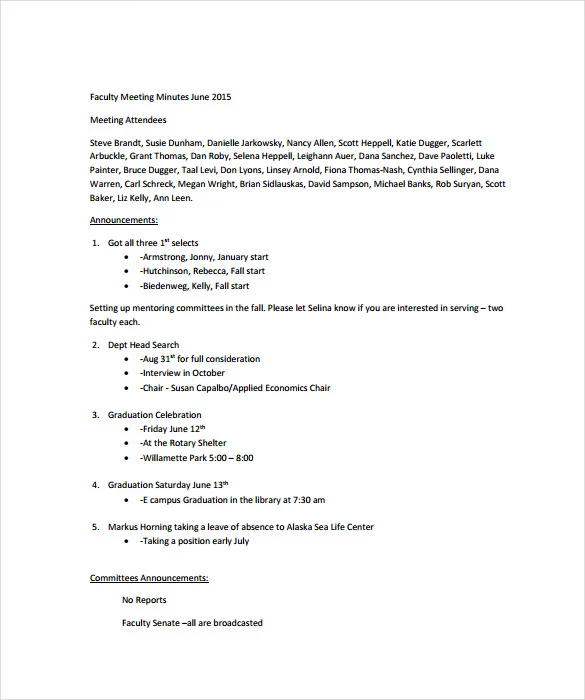

In [42]:
input_image

In [43]:
layoutlm_feature_extractor = LayoutLMv3FeatureExtractor(apply_ocr=True, ocr_lang="eng")
layoutlm_image_processor =  LayoutLMv3ImageProcessor(apply_ocr=True, ocr_lang="eng")
layoutlm_tokenizer = LayoutLMv3TokenizerFast.from_pretrained("microsoft/layoutlmv3-base")
layoutlm_processor = LayoutLMv3Processor(layoutlm_feature_extractor, layoutlm_tokenizer)

/home/onyx/.local/lib/python3.10/site-packages/transformers/models/layoutlmv3/feature_extraction_layoutlmv3.py:30: FutureWarning: The class LayoutLMv3FeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use LayoutLMv3ImageProcessor instead.
  warnings.warn(


In [44]:
layoutlm_processor_encoding = layoutlm_processor(
    input_image,
    max_length = 512,
    padding = "max_length",
    truncation = True,
    return_tensors = "pt"
)

layoutlm_processor_encoding.keys()

dict_keys(['input_ids', 'attention_mask', 'bbox', 'pixel_values'])

In [45]:
print(f"""
input_ids:  { list(layoutlm_processor_encoding["input_ids"].squeeze().shape) }
word boxes: { list(layoutlm_processor_encoding["bbox"].squeeze().shape) }
image data: { list(layoutlm_processor_encoding["pixel_values"].squeeze().shape) }
image size: { input_image.size }
""")


input_ids:  [512]
word boxes: [512, 4]
image data: [3, 224, 224]
image size: (585, 700)



In [46]:
layoutlm_features = layoutlm_feature_extractor(input_image)
layoutlm_image = layoutlm_image_processor(input_image)

In [47]:
print(f"""
--- layoutlm_feature_extractor ---
image size: { layoutlm_features["pixel_values"][0].shape }
word count: { len(layoutlm_features["words"][0]) }
word boxes: { len(layoutlm_features["boxes"][0]) }
""")

print(f"""
--- layoutlm_image_processor ---
image size: { layoutlm_image["pixel_values"][0].shape }
word count: { len(layoutlm_image["words"][0]) }
word boxes: { len(layoutlm_image["boxes"][0]) }
""")


--- layoutlm_feature_extractor ---
image size: (3, 224, 224)
word count: 172
word boxes: 172


--- layoutlm_image_processor ---
image size: (3, 224, 224)
word count: 172
word boxes: 172



In [48]:
input_image_pixel_values = layoutlm_features["pixel_values"][0]
input_image_words = layoutlm_features["words"][0]
input_image_bounding_boxes = layoutlm_features["boxes"][0]
input_image_bounding_boxes

[[155, 132, 201, 145],
 [206, 134, 263, 145],
 [263, 117, 321, 157],
 [326, 117, 357, 157],
 [362, 132, 394, 142],
 [155, 150, 208, 190],
 [213, 150, 276, 190],
 [153, 200, 191, 208],
 [196, 198, 244, 211],
 [249, 200, 283, 208],
 [288, 198, 345, 208],
 [353, 182, 406, 222],
 [411, 182, 485, 222],
 [490, 200, 531, 211],
 [536, 198, 574, 210],
 [579, 198, 611, 208],
 [617, 198, 668, 211],
 [678, 198, 711, 208],
 [716, 200, 757, 211],
 [772, 198, 823, 208],
 [153, 217, 217, 228],
 [222, 201, 259, 241],
 [263, 201, 319, 241],
 [326, 218, 352, 227],
 [357, 217, 394, 230],
 [400, 217, 442, 227],
 [447, 217, 499, 230],
 [512, 201, 565, 241],
 [572, 201, 608, 241],
 [613, 218, 647, 227],
 [652, 217, 711, 228],
 [716, 218, 748, 227],
 [753, 217, 805, 227],
 [815, 217, 844, 227],
 [153, 221, 206, 261],
 [210, 221, 249, 261],
 [254, 221, 302, 261],
 [311, 221, 338, 261],
 [343, 221, 372, 261],
 [374, 221, 403, 261],
 [405, 221, 451, 261],
 [452, 221, 494, 261],
 [494, 221, 550, 261],
 [555, 221,

### Converting input_image_pixel_values into a usable image to see what the transformers sees (just for understanding)

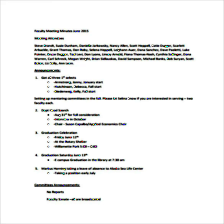

In [49]:

input_image_pixel_values = input_image_pixel_values.transpose(1, 2, 0)
input_image_pixel_values = np.uint8(input_image_pixel_values * 255)

Image.fromarray(input_image_pixel_values, mode="RGB")

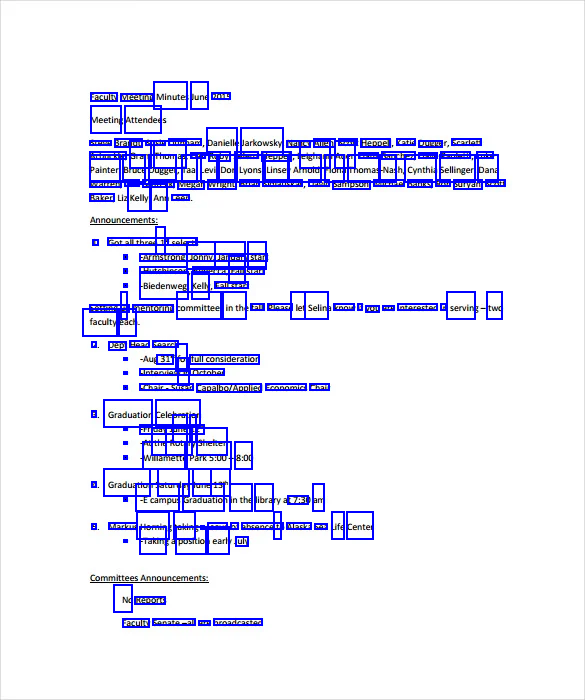

In [50]:
draw_image = input_image.copy()
width_scale = input_image_width / 1000
height_scale = input_image_height / 1000

draw = ImageDraw.Draw(draw_image)

for bbox in input_image_bounding_boxes:
  draw.rectangle(
      [
          bbox[0] * width_scale,
          bbox[1] * height_scale,
          bbox[2] * width_scale,
          bbox[3] * height_scale,
      ],
      outline = "blue",
      width = 2
  )

draw_image

In [51]:
layoutlm_tokenizer_encoding = layoutlm_tokenizer(
    text = input_image_words,
    boxes = input_image_bounding_boxes,
    max_length = 512,
    padding = "max_length",
    truncation = True,
    return_tensors = "pt"
)

In [52]:
input_image_tokens = layoutlm_tokenizer.convert_ids_to_tokens(
    layoutlm_tokenizer_encoding["input_ids"][0],
    skip_special_tokens=True
)

layoutlm_tokenizer.convert_tokens_to_string(input_image_tokens)

' Faculty Meeting Mlouts une 2015 Meeting Attendees ‘Stove Brandt, Susie Dunham, Danelle Jarkowsy, Nancy Ale, Scott Heppel, Katle Dugger, Sealett ‘rbuce, Grant Thomas, Oan Raby, Selena Hepp, eighann Aue, Oana Sancher Dave Pale Luke Painter, Brace Dugger, Tal Lev, Don Lyons, Linsey Arnal, Fona Thomas Nash Cynthia Sellger, Dana Warten ad Schreck, Megan Wright, rian Silbuska, David Sampson, Michael Banks, Rab Sura, Sott ‘Baker, Kel, Ann Leen. 2, Gotallthvee 2 slats ‘+ Aemstong, sonny, January start 1+ uteinson, Rebecca, Fall start + Bledenwes, ely Fallstart ‘Setung up mentring commitee inthe fl lease lt Selina know if you are intrested in serving two facuty exc. 2 Dept Head Search ‘+g 31" for fullennsideration “+ -lmerview in October ‘+ -Chair-Susan Capalbe/Applied Economies Chat 3. Graduation Celebration + Friday ne 12 + the Rotary shelter 4+ lett Parks:00~ 8:00 4. Graduation sturdy une 33" ‘+ -Ecampus Graduation nthe Har 730 arn ‘5. Markus Horning taking a eave of absence to Alaska Sea 

In [53]:
detr_feature_extractor = DetrFeatureExtractor()
detr_image_processor = DetrImageProcessor()
detr_feature_extractor_encoding = detr_feature_extractor(input_image, return_tensors="pt")
detr_image_processor_encoding = detr_image_processor(input_image, return_tensors="pt")
detr_feature_extractor_encoding.keys()

/home/onyx/.local/lib/python3.10/site-packages/transformers/models/detr/feature_extraction_detr.py:28: FutureWarning: The class DetrFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use DetrImageProcessor instead.
  warnings.warn(


dict_keys(['pixel_values', 'pixel_mask'])

In [54]:
table_detection_model = TableTransformerForObjectDetection.from_pretrained("microsoft/table-transformer-detection")

with torch.no_grad():
  outputs = table_detection_model(**detr_feature_extractor_encoding)

outputs.keys()

odict_keys(['logits', 'pred_boxes', 'last_hidden_state', 'encoder_last_hidden_state'])

In [55]:
COLORS = [[0.000, 0.447, 0.741], [0.850, 0.325, 0.098], [0.929, 0.694, 0.125],
          [0.494, 0.184, 0.556], [0.466, 0.674, 0.188], [0.301, 0.745, 0.933]]

def plot_results(pil_img, scores, labels, boxes, model):
    plt.figure(figsize=(16,10))
    plt.imshow(pil_img)
    ax = plt.gca()
    colors = COLORS * 100
    for score, label, (xmin, ymin, xmax, ymax),c  in zip(scores.tolist(), labels.tolist(), boxes.tolist(), colors):
        ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                   fill=False, color=c, linewidth=3))
        text = f'{model.config.id2label[label]}: {score:0.2f}'
        ax.text(xmin, ymin, text, fontsize=15,
                bbox=dict(facecolor='yellow', alpha=0.5))
    plt.axis('off')
    plt.show()

In [56]:
detr_feature_extractor

DetrFeatureExtractor {
  "do_normalize": true,
  "do_pad": true,
  "do_rescale": true,
  "do_resize": true,
  "format": "coco_detection",
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "DetrFeatureExtractor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "longest_edge": 1333,
    "shortest_edge": 800
  }
}

In [57]:
results = detr_feature_extractor.post_process_object_detection(outputs, threshold=0.7, target_sizes=[(input_image_height, input_image_width)])[0]

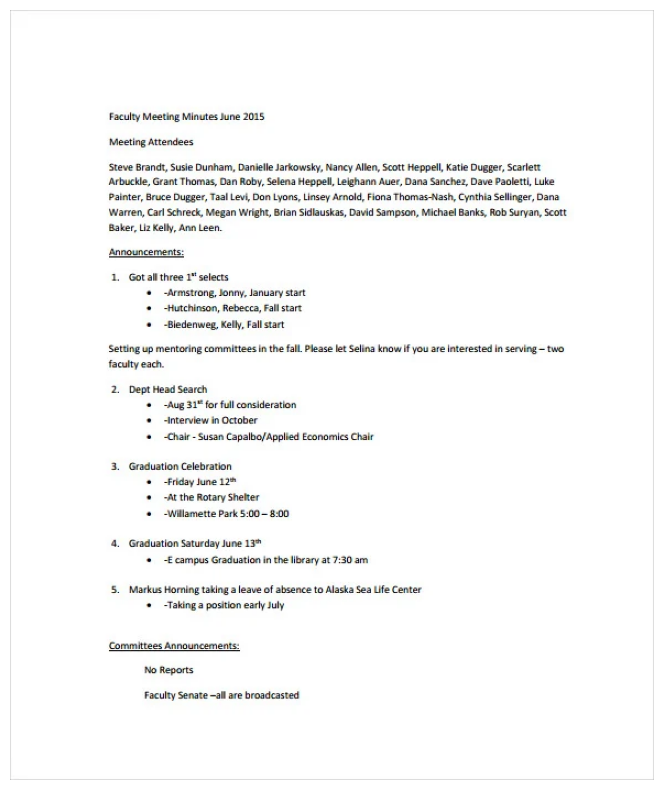

In [58]:
plot_results(input_image, results['scores'], results['labels'], results['boxes'], table_detection_model)

In [59]:
results

{'scores': tensor([]),
 'labels': tensor([], dtype=torch.int64),
 'boxes': tensor([], size=(0, 4))}

If more tables, start from here with refactor

In [60]:
(table_xmin, table_ymin, table_xmax, table_ymax) = zip(results['boxes'][0].tolist())
table_image = input_image.crop((table_xmin[0] - 30, table_ymin[0] - 30, table_xmax[0] + 40, table_ymax[0] + 25))

IndexError: index 0 is out of bounds for dimension 0 with size 0

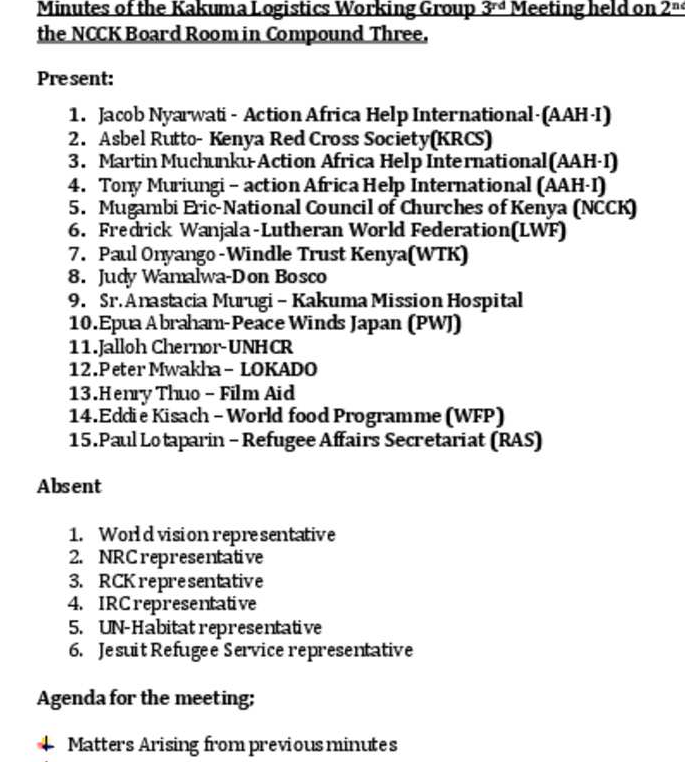

In [61]:
table_image

In [62]:
detr_table_feature_extractor_encoding = detr_feature_extractor(table_image, return_tensors="pt")
detr_table_feature_extractor_encoding.keys()

dict_keys(['pixel_values', 'pixel_mask'])

In [63]:
table_structure_model = TableTransformerForObjectDetection.from_pretrained("microsoft/table-transformer-structure-recognition")

with torch.no_grad():
  table_outputs = table_structure_model(**detr_table_feature_extractor_encoding)

table_outputs.keys()

odict_keys(['logits', 'pred_boxes', 'last_hidden_state', 'encoder_last_hidden_state'])

In [64]:
target_sizes = [table_image.size[::-1]]
table_results = detr_feature_extractor.post_process_object_detection(table_outputs, threshold=0.6, target_sizes=target_sizes)[0]
table_results

{'scores': tensor([0.9221, 0.9435, 0.7974, 0.8029, 0.7767, 0.7586, 0.9802, 0.8818, 0.7152,
         0.9867, 0.8408, 0.9767, 0.6410, 0.8262, 0.9687, 0.7489, 0.9998]),
 'labels': tensor([2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 4, 2, 2, 4, 4, 2, 0]),
 'boxes': tensor([[ 34.3239, 462.9223, 635.6955, 517.9020],
         [ 34.6484, 634.3357, 635.6027, 680.0724],
         [ 34.4655, 273.4374, 635.3006, 346.7931],
         [ 34.3523, 422.7278, 635.7267, 466.8908],
         [ 34.8552, 132.4834, 635.0427, 277.7236],
         [ 35.2593,  93.6014, 635.7988, 127.3566],
         [ 31.8026,  63.4812, 590.1402, 709.8895],
         [ 34.2705, 508.8099, 636.0578, 563.3631],
         [ 34.8449, 607.3452, 635.6934, 635.9213],
         [ 34.8154,  64.7321, 635.7730,  93.8650],
         [ 33.8867, 490.2715, 636.1855, 534.8898],
         [ 34.7785, 680.4495, 635.4798, 707.7190],
         [ 34.4283, 584.8978, 635.9420, 614.1978],
         [ 34.5305,  92.9376, 636.3035, 125.0376],
         [ 35.0802,  64.5572, 636.1170,

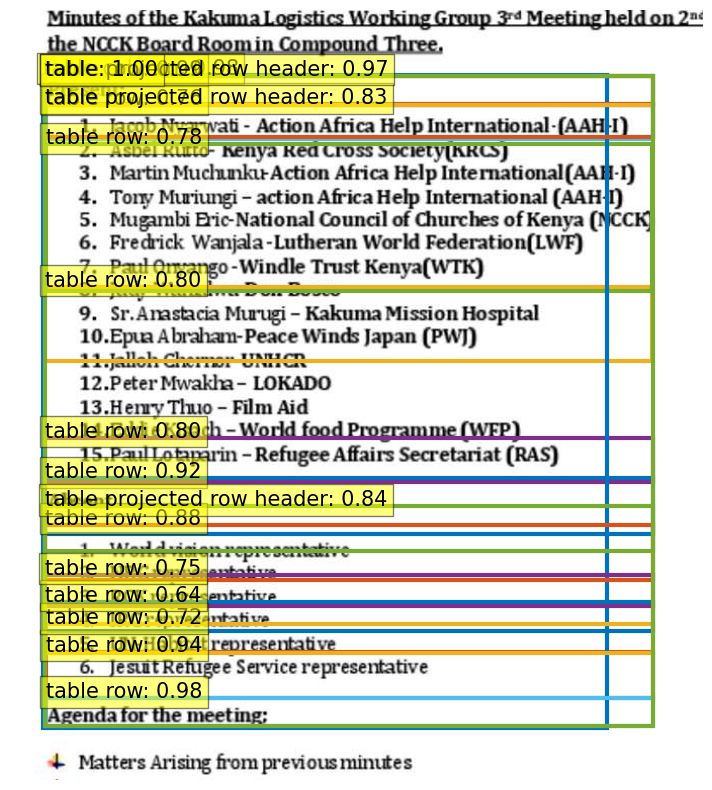

In [65]:
plot_results(table_image, table_results['scores'], table_results['labels'], table_results['boxes'], table_structure_model)

In [27]:
table_structure_model.config.id2label

{0: 'table',
 1: 'table column',
 2: 'table row',
 3: 'table column header',
 4: 'table projected row header',
 5: 'table spanning cell'}

### Columns

In [28]:
column_scores = list()
column_labels = list()
column_boxes = list()

table_scores = table_results['scores'].tolist()
table_labels = table_results['labels'].tolist()
table_boxes = table_results['boxes'].tolist()

for idx, label in enumerate(table_labels):
    if label == 1:
        column_scores.append(table_scores[idx])
        column_labels.append(label)
        column_boxes.append(table_boxes[idx])
    
column_scores = torch.tensor(column_scores)
column_labels = torch.tensor(column_labels)
column_boxes = torch.tensor(column_boxes)

In [29]:
column_scores

tensor([0.9802])

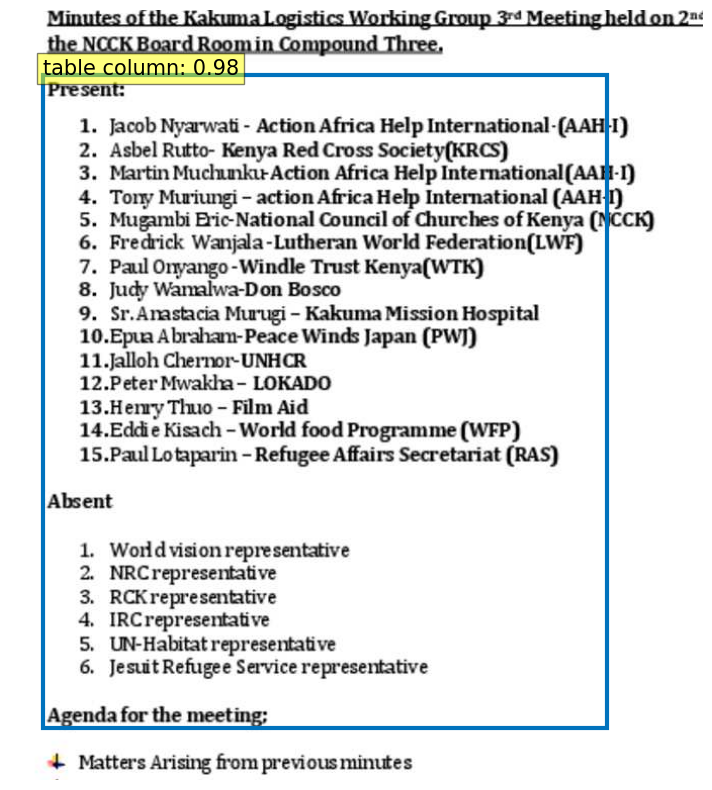

In [30]:
plot_results(table_image, column_scores, column_labels, column_boxes, table_structure_model)

### Rows

In [31]:
row_scores = list()
row_labels = list()
row_boxes = list()

table_scores = table_results['scores'].tolist()
table_labels = table_results['labels'].tolist()
table_boxes = table_results['boxes'].tolist()

for idx, label in enumerate(table_labels):
    if label == 2:
        row_scores.append(table_scores[idx])
        row_labels.append(label)
        row_boxes.append(table_boxes[idx])
    
row_scores = torch.tensor(row_scores)
row_labels = torch.tensor(row_labels)
row_boxes = torch.tensor(row_boxes)

In [32]:
print(row_boxes)

tensor([[ 34.3239, 462.9223, 635.6955, 517.9020],
        [ 34.6484, 634.3357, 635.6027, 680.0724],
        [ 34.4655, 273.4374, 635.3006, 346.7931],
        [ 34.3523, 422.7278, 635.7267, 466.8908],
        [ 34.8552, 132.4834, 635.0427, 277.7236],
        [ 35.2593,  93.6014, 635.7988, 127.3566],
        [ 34.2705, 508.8099, 636.0578, 563.3631],
        [ 34.8449, 607.3452, 635.6934, 635.9213],
        [ 34.8154,  64.7321, 635.7730,  93.8650],
        [ 34.7785, 680.4495, 635.4798, 707.7190],
        [ 34.4283, 584.8978, 635.9420, 614.1978],
        [ 34.1365, 558.4930, 635.9337, 589.4976]])


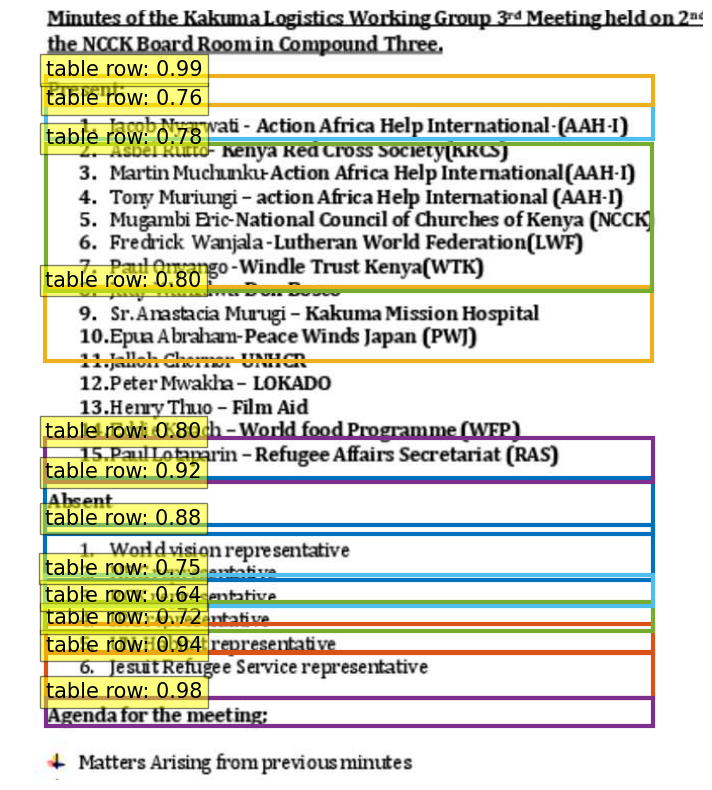

In [33]:
plot_results(table_image, row_scores, row_labels, row_boxes, table_structure_model)

# Attempting to get cells

In [34]:
rows = row_boxes.tolist()
columns = column_boxes.tolist()

cell_scores = list()
cell_labels = list()
cell_boxes = list()

for r in range(len(rows)):
    r_xmin = rows[r][0]
    r_ymin = rows[r][1]
    r_xmax = rows[r][2]
    r_ymax = rows[r][3]
    for c in range(len(columns)):
        c_xmin = columns[c][0]
        c_ymin = columns[c][1]
        c_xmax = columns[c][2]
        c_ymax = columns[c][3]
        
        n_xmin = max(r_xmin, c_xmin)
        n_ymin = max(r_ymin, c_ymin)
        n_xmax = min(r_xmax, c_xmax)
        n_ymax = min(r_ymax, c_ymax)
        
        cell_scores.append(0.99)
        cell_labels.append(1)
        cell_boxes.append([n_xmin, n_ymin, n_xmax, n_ymax])
        
print(cell_boxes)
        
cell_scores = torch.tensor(cell_scores)
cell_labels = torch.tensor(cell_labels)
cell_boxes = torch.tensor(cell_boxes)

[[34.32388687133789, 462.9222717285156, 590.1401977539062, 517.9020385742188], [34.648380279541016, 634.335693359375, 590.1401977539062, 680.0723876953125], [34.46552658081055, 273.4373779296875, 590.1401977539062, 346.7930908203125], [34.352264404296875, 422.727783203125, 590.1401977539062, 466.8907775878906], [34.85519790649414, 132.48341369628906, 590.1401977539062, 277.7236022949219], [35.25932693481445, 93.60140228271484, 590.1401977539062, 127.35658264160156], [34.270484924316406, 508.8099365234375, 590.1401977539062, 563.3630981445312], [34.84490966796875, 607.3451538085938, 590.1401977539062, 635.9213256835938], [34.8154296875, 64.73213958740234, 590.1401977539062, 93.86499786376953], [34.778541564941406, 680.449462890625, 590.1401977539062, 707.718994140625], [34.428348541259766, 584.8977661132812, 590.1401977539062, 614.19775390625], [34.13654327392578, 558.4929809570312, 590.1401977539062, 589.49755859375]]


In [35]:
print(cell_boxes)

tensor([[ 34.3239, 462.9223, 590.1402, 517.9020],
        [ 34.6484, 634.3357, 590.1402, 680.0724],
        [ 34.4655, 273.4374, 590.1402, 346.7931],
        [ 34.3523, 422.7278, 590.1402, 466.8908],
        [ 34.8552, 132.4834, 590.1402, 277.7236],
        [ 35.2593,  93.6014, 590.1402, 127.3566],
        [ 34.2705, 508.8099, 590.1402, 563.3631],
        [ 34.8449, 607.3452, 590.1402, 635.9213],
        [ 34.8154,  64.7321, 590.1402,  93.8650],
        [ 34.7785, 680.4495, 590.1402, 707.7190],
        [ 34.4283, 584.8978, 590.1402, 614.1978],
        [ 34.1365, 558.4930, 590.1402, 589.4976]])


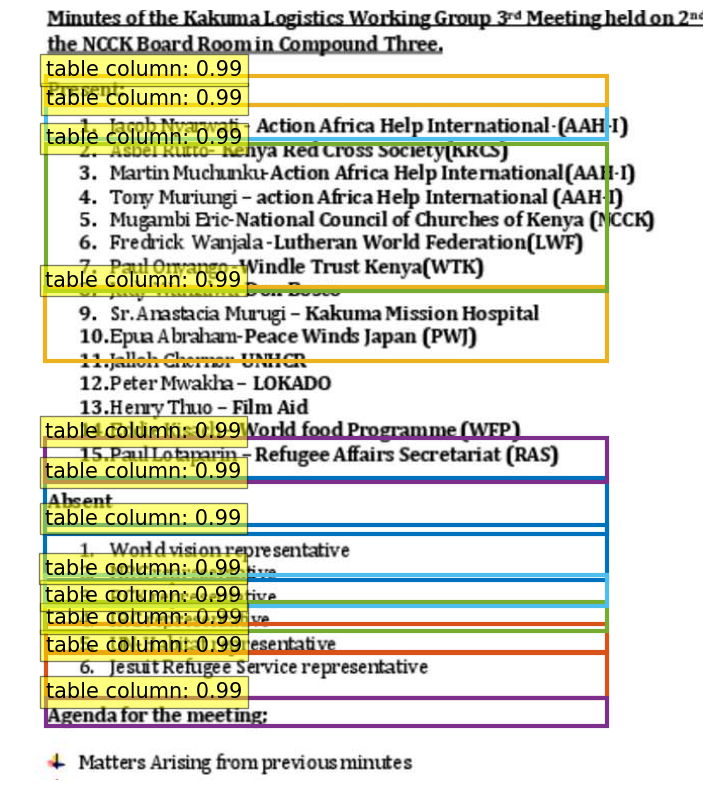

In [36]:
plot_results(table_image, cell_scores, cell_labels, cell_boxes, table_structure_model)

### Process word and cell bounding boxes to fit original image

In [66]:
cell_boxes_fit = cell_boxes.tolist().copy()
input_image_bounding_boxes_fit = input_image_bounding_boxes.copy()

width_scale = input_image_width / 1000
height_scale = input_image_height / 1000

for bbox in input_image_bounding_boxes_fit:
  bbox[0] = bbox[0] * width_scale
  bbox[1] = bbox[1] * height_scale
  bbox[2] = bbox[2] * width_scale
  bbox[3] = bbox[3] * height_scale

for cb in cell_boxes_fit:
    cb[0] = cb[0] + table_xmin[0] - 30
    cb[1] = cb[1] + table_ymin[0] - 30
    cb[2] = cb[2] + table_xmin[0] - 30
    cb[3] = cb[3] + table_ymin[0] - 30
    
cell_boxes_fit = torch.tensor(cell_boxes_fit)

Can do tests for efficiency if needed in below function (First box to fit, euclidean distance over dataset etc.)
Can extrapolate only the text in the region of the table such that whole dataset isn't used everytime

In [67]:
table_words = list()
non_table_words = input_image_words.copy()

def center_in_box(x_center, y_center, bbox):
    x1, y1, x2, y2 = bbox
    return x1 <= x_center <= x2 and y1 <= y_center <= y2

# Frist word
def find_word(cell: list):
    return_word = ""
    
    for idx, bbox in enumerate(input_image_bounding_boxes_fit):
        center = ((bbox[0] + bbox[2]) / 2, (bbox[1] + bbox[3]) / 2)
        if center_in_box(center[0], center[1], cell):
            return_word = input_image_words[idx]
            non_table_words[idx] = ''
            break
        
    return return_word

In [39]:
row_count = len(rows)
column_count = len(columns)

for row_idx in range(row_count):
    row_words = list()
    for column_idx in range(column_count):
        word_in_cell = find_word(cell_boxes_fit[((row_idx * column_count) + column_idx)].tolist())
#         row_words.append(word_in_cell)
        table_words.append(word_in_cell)
#     table_words.append(row_words)
    
print(table_words)

['Absent', 'Jesuit', 'Judy', '15.Paul', '2.', '1.', 'World', 'UN-Habitat', 'Present:', 'Agenda', 'IRCrepresentative', 'RCKrepresentative']


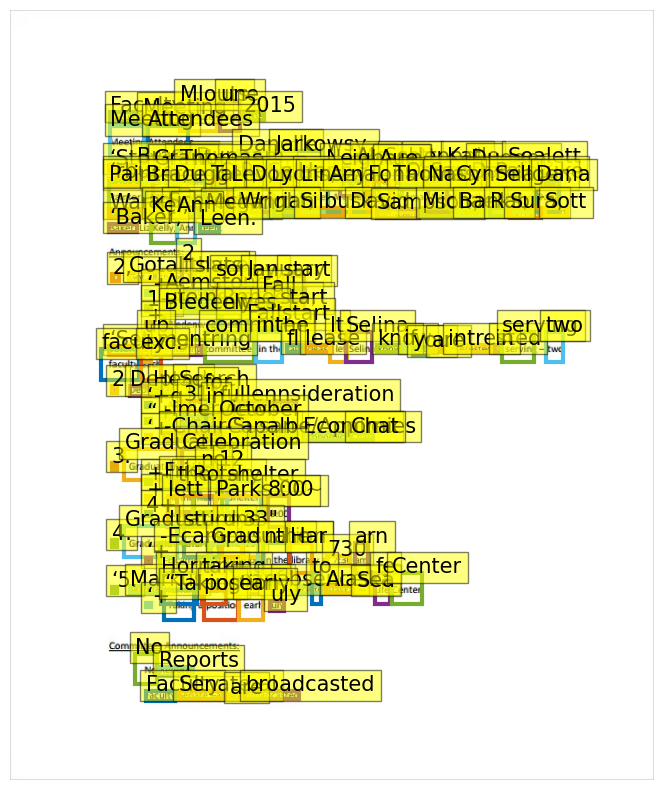

In [68]:
COLORS = [[0.000, 0.447, 0.741], [0.850, 0.325, 0.098], [0.929, 0.694, 0.125],
          [0.494, 0.184, 0.556], [0.466, 0.674, 0.188], [0.301, 0.745, 0.933]]

plt.figure(figsize=(16,10))
plt.imshow(input_image.copy())
ax = plt.gca()
colors = COLORS * 100

for label, (xmin, ymin, xmax, ymax), c  in zip(table_words, cell_boxes_fit.tolist(), colors):
    ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                               fill=False, color=c, linewidth=3))
    text = f"{label if label != '' else 'empty'}"
    ax.text(xmin, ymin, text, fontsize=15,
            bbox=dict(facecolor='yellow', alpha=0.5))
    
for label, (xmin, ymin, xmax, ymax), c  in zip(non_table_words, input_image_bounding_boxes_fit, colors):
    if label != '':
        ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                               fill=False, color=c, linewidth=3))
        text = f'{label}'
        ax.text(xmin, ymin, text, fontsize=15,
                bbox=dict(facecolor='yellow', alpha=0.5))
plt.axis('off')
plt.show()